<a href="https://colab.research.google.com/github/ykim68ncstate/ST554-homwork_Yujin-Kim/blob/main/ST554_HW5_YujinKimipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ST 554 Analysis of BigData - HW5
Name: Yujin Kim

Course: ST 554 (601) Spring 2026 Analysis of Big Data

Assignment: Homework #5

## Part I. Concepts

**Big data Example Abstract**

Building energy data have been used for decades to understand energy flows within buildings and to forecast future energy demand. Due to market, technological, and policy drivers, stakeholders across the building industry are now collecting data at an unprecedented scale. Integrating indipendently collected and managed datasets provides a cost-effective opportunity to construct databases of unprecedented size.

This paper uses the U.S. department of Energy (DOE) Building Performance Database (BPD) as a case study to discuss the technical considerations involved in building such a database. Data from more than 750,000 residential and commerical buildings were collected.


**Reference:**
Mathew, P., Dunn, L., Sohn, M., Mercado, A., Custudio, C., Walter, T. (2015). Big-data for building energy performance: Lessons from assembling a very large national database of building energy use, Applied Energy, 140, 15, 85-93.
[Paper link](https://www.sciencedirect.com/science/article/pii/S0306261914012112)

### (1) Five V's of Big Data
**Instruction:** We discussed the “Five V’s of Big Data”. Give an example of a place where you’ve encountered big data or a topic you are interested in where big data would arise. Specifically address the five V’s for the example and whether/how they apply to your example.


#### **Volume**
Volume refers to the large scale of the dataset. The Building Performance Database includes data from hundreds of thousands of buildings, with at least one year of energy consumption data for each building. When considering that each building may include annual, monthly, or period-level energy records, the total number of observations becomes substantial. Compared to traditional survey-based datasets, this large volume enables more detailed statistical analyses, subgroup comparisons, and distribution-based estimates of energy performance and savings.

#### **Velocity**
Velocity describes the continuous generation and updating of data. Building energy data are increasingly collected through smart meters, benchmarking platforms, and energy disclosure policies. As a result, new data are continually added to the system rather than collected once at a single point in time. This ongoing data accumulation allows for periodic updates to analyses and supports more timely decision-making. With higher time-resolution data (e.g., monthly or hourly records), the database could also support near real-time monitoring or operational diagnostics.

#### **Variety**
Variety refers to the diversity of data sources, formats, and types. The Building Performance Database integrates data from cities, utilities, efficiency programs, and private portfolio owners, each of which may collect and store information differently. The dataset includes not only whole-building energy consumption but also building characteristics (such as floor area, climate zone, and building type), and in some cases system-level information (HVAC, lighting, envelope components) and retrofit measures. Because data formats and naming conventions differ across sources, mapping them into a common structure is necessary. This heterogeneity of structure and content illustrates the strong presence of variety in this example.

#### **Veracity**
Veracity concerns data quality, uncertainty, and bias. Building energy data collection is relatively recent, and standardized quality control procedures are not always established. The dataset may contain missing values, inconsistent entries, estimated rather than measured data, or buildings that are not representative of the national building stock. For example, some regions or portfolio types may be overrepresented, creating sampling bias. In addition, system-level data are often incomplete. Therefore, data cleaning, validation, and careful interpretation are essential to ensure reliable conclusions. The presence of uncertainty and potential bias makes veracity a critical issue in this case.

#### **Value**
Value represents the usefulness of the data for decision-making. Large-scale empirical energy data can support plicymakers, building owners, and investors by providing evidence-based insights into building performance. In particular, empirical data can complement or validate engineering-based simulation models, which sometimes overestimate savings. By estimating the probability distribution of energy svaings rather than a single deterministic value, the database can help quantify uncertainty and investment risk, which is especially important in performance-based energy service contracts. Thus, the dataset creates meaningful value beyond simple data accumulation.

### (2) CRUD Examples in the Context of the SQLite Baseball Archive
**Instruction:** Read about the database we’ll use below (part IV). Give an example for each letter in the CRUD acronym in the context of this database.


The SQLite Baseball Archive contains historical Major League Baseball statistics dating back to 1871, including information on players, teams, managers, and Hall of Fame records.


#### **Create**
An example of Create would be adding a new player's record to the `players` table if a new MLB player debuts. This would involve inserting a new row with attributes such as `playerID`, name, birth year, and other biographcial information.

#### **Read**
An example of Read would be retrieving all teams that played in the 2015 season from the `Teams` table. This operation would involve selecting rows where `YearID = 2015` and examining statistics such as wins, losses ,and team rankings. This type of query allows users to analyze historical baseball performance without modifying the database.

#### **Update**
An example of Update would be correcting an error in a manager's seasonal record in the `Managers` table. If a win or loss total was entered incorrectly for a specific `playerID` and `yearID`, the record could be updated to refelct the correct statistics while preserving the rest of the dataset.

#### **Delete**
An example of Delete would be removing duplicate or erroneous entries from the database. For instance, if the same manager-season record was mistakenly entered twice in the `Managers` table, one of the duplicate rows could be deleted to ensure accurate aggregation of career statistics.

### (3) Purpose of the HAVING Clause in SQL
**Instruction:** What is the purpose of the HAVING clause when writing SQL code? (Recall the sqlitetutorial.net tutorial on the SELECT statement.)

The HAVING clause in SQL is used to specify a search condition for a group after rows have been grouped using the `Group By` clause. It filters aggregated results based on a Boolean condition.

Unlike the `Where` clause, which filters individual rows before grouping occurs, the `HAVING` clause is applied after the `Group By` clause and evalutes conditions on aggregate fuctions such as `Count()`, `Sum()`, `Avg()`, `Min()`, or `Max()`.

Because the HAVING cluase operates on groups, it must be used together with a `Group By` clause. If a HAVING clause is used without Group By, an error will occur.

For example, if we group records by a column and calculate the total count using `Count()`, we can use the HAVING clause to include only those groups where the count meets a specified condition. Therefore, the HVAING clause allows us to filter groups based on aggregated values rather than individual rows.

[SQLite Having](https://www.sqlitetutorial.net/sqlite-having/)

## Part II. Simulation of a Sampling distribution


###(4) **Instruction:** We looked at using simulation to investigate the sampling distribution of $\hat{p}$ in the notes. We’ll now look at the sampling distribution of the sample slope from an SLR model using simulation.

* Recall we assume the following model for SLR:
\\[Y_i = β_0 + β_1x_i + E_i\\]
where the $E_i$ are assumed to be indendent and identically distributed from a Normal distribution with mean $0$ and variance $σ^2$. Let’s assume $σ^2 = 1$ for simplicity.

* We can generate data from this model by assuming values for β0, β1, and n, along with a sequence of x values via the following code:



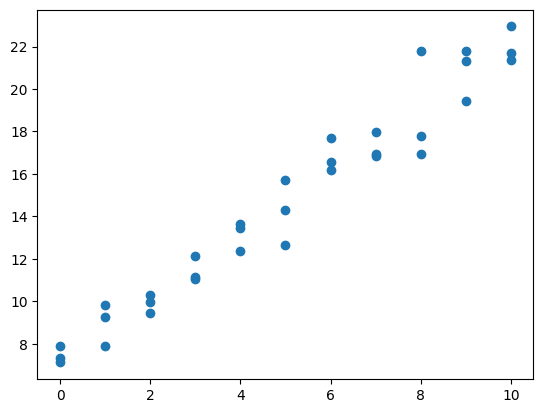

In [ ]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y)
plt.show()

####(a) Now we can use sklearn to obtain the estimate for the slope (and save that value) as we did earlier in the course.

In [ ]:
from sklearn.linear_model import LinearRegression

X = x.reshape(-1, 1) #sklearn requires the input data to be in a 2D array format.

model = LinearRegression() #create an empty linear regression model
model.fit(X, y) # fit the model to the data

slope_hat = model.coef_[0] # store the estimated slope (_ indicates that the attribute is created after the model is fitted.)
intercept_hat = model.intercept_ #store the estimated intercept

slope_hat, intercept_hat

(np.float64(1.4745056382493755), np.float64(7.259043801350283))

####(b) Repeat the above process 5000 times. To be specific: (11 pts)

  – Generate the y values using the code with rng.standard_normal()

  – Find the ‘best’ slope via sklearn

  – Save that slope in some object



In [ ]:
n_sim = 5000
slopes = np.empty(n_sim)  # array for store slopes

for i in range(n_sim):
    y = beta_0 + beta_1 * x + rng.standard_normal(n) # generate y
    model = LinearRegression() # fit using sklearn
    model.fit(X, y)
    slopes[i] = model.coef_[0] #store best slope

slopes[:10], slopes.shape

(array([1.45280552, 1.53315358, 1.47203179, 1.44166898, 1.48156797,
        1.52223225, 1.44189032, 1.49381054, 1.52642257, 1.61850999]),
 (5000,))

####(c) We can use the many values of the sample slope as an approximation to the sampling distribution of the sample slope! Create a histogram of the sample slope values you found. (3 pts)

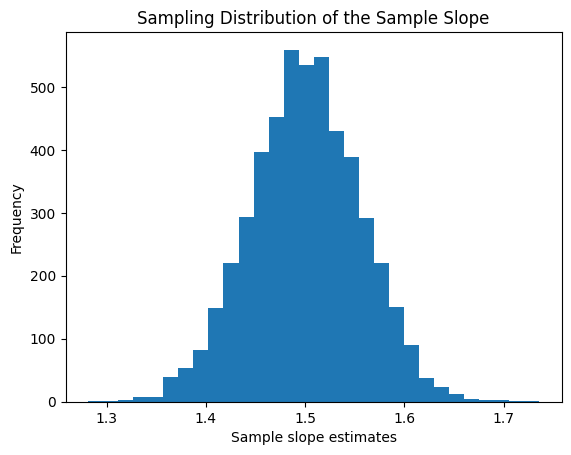

In [ ]:
plt.hist(slopes, bins = 30)
plt.xlabel("Sample slope estimates")
plt.ylabel("Frequency")
plt.title("Sampling Distribution of the Sample Slope")
plt.show()

The histogram of the simulated slope estimates appears approximately normally distributed and centered around the slope value $β_1 = 1.5$.

####(d) Use your sampling distribution to approximate the probability of observing a sample slope larger than 1.65. This can be done by looking at the proportion of simulated values larger than 1.65. (3 pts)


In [ ]:
prob_165 = np.mean(slopes > 1.65)
prob_165

np.float64(0.0038)

In [ ]:
np.sum(slopes > 1.65)

np.int64(19)

The estimated probability that the sample slope exceeds 1.65 is approximately 0.38%. this value was calculated as the proportion of simulated slope estimate greater than 1.65 out of 5000 simulations.

####(e) Give an interpretation of this value and why it might be important for us in relation to a hypothesis test. (3 pts)

The estimated probability that the sample slope exceeds 1.65 is approximately 0.0038. This means that when the true slope is 1.5, it is very unlikely to observe a slope as large as 1.65 due to random variation in the data.

This is important because it shows how we can use simulation to understand the sampling variability of the slope estimator. Even though each dataset is noisy, fitting the model with sklearn repeatedly produces a distribution of slope estimates centered near the true value. That distribution lets us quantify how "unusual" a particular slope estimate (like 1.65) would be when the underlying slope is 1.5, which supports statistical interpretation of the fitted slope beyond a single run of the regression.

## Part III. Big Data Xeamples & Rare Events

### (5) Consider this article about bias in machine learning models
**Biases in machine learning models and big data analytics: The international criminal and humanitarian law implication**

**Instruction:** Consider this article about bias in machine learning models
* Pick an example in the article and briefly outline the issue around the data used to fit the model. (3 pts)
* Describe how we might augment the data or otherwise account for the bias in that situation. (3 pts)

**Reporting Bias Example in Article**

One example of reporting bias discussed in the article concerns user-generated content (UGC) on social media. The article explains that big data often refects the behavior of those who generate content online rather than the true distribution of events in the real world. Not everyone has equal access to the internet, and even among users, a small fraction produces most of the content. For example, a small percentage of Twitter users generate the majority of tweets. As a result, the data reflects the demographic composition and activity patterns of content producers rather than the broader population. this creates a distorted dataset, where observed frequencies do not necessarily represent reality.

**Related Example in the Building Performance Data**

A similar form of reporting bias can occur in building energy applications. In many smart buildings, machine learning models rely on sensor data to learn occupancy patterns and dynamic load behavior. However, the data collected by sensors may not fully represent actual building conditions. Some spaces may lack sensors, cetain behaviors may not be directly measured, and sensor malfunctions can introduce erroneous signals. In this case, the "reported" building data reflects what sensors capture, not necessarily what truly occurs in the building. As in the social media example, the observed dataset may systematically differ from the real-world process it aims to model.

**Strategies to Mitigate Reporting Bias**

Reporting bias can be addressed directly during model training by recognizing that sensor and occupancy data may be imcomplete or noisy representations of reality. Instead of treating these inputs as fully accurate, models can incorporate uncertainty-aware approaches, such as treating occupancy as a latent variable or using robust training techniques that reduce sensitivity to systematic measurement errors. Evaluating performance under differetn operating conditions can also reveal overfitting to biased patterns. by accounting for uncertainty during training, machine learning model can remain reliable even when the underlying data are imperfect.

### (6) Consider this article about big data usage in the Earth Sciences

**Big data in Earth science: Emerging practice and promise**

**Instruction:** Choose one of the three major areas the paper discusses. Summarize the use of big data there. Are there any biases or other missing data that might affect results? (I know this is likely difficult as most of us aren’t experts in Earth science - just do your best - my goal is to try to get us to always ask questions about the data collected and used for a study!) (5 pts)

**Atmospheric modeling: Global climate models**

Atmospheric science and climate modeling rely heavily on long-term and large-scale datasets. climate observations span decades to centuries and include a wide variety of variables such as temperature, precipitaiton, wind speed, atmospheric pressure, and greenhouse gas concentrations. These datasets also exhibit strong temporal characteristics: come measurements are recorded monthly or annually, while otehrs are collected at hourly or even second-level resolution. Because of this diversity in temporal scaels and measurement types, climate science operates within an extremely large and complex data environment. big data enable researchers to identify long-term trends and genralize patterns across space and time. However, although climate data often reveal large-scale trends, they also contain substantial variability within those trends. this intrinsic variability makes interpretation and modeling more challenging, as short-term fluctuations may coexist with long-term directional change.

Several biases and data limitations can affect climate modeling results. First, observational data are unevely distributed geographically, with denser monitoring networks in developed regions and sparce coverage in remote or oceanic areas. Second, data quality issues-such as missing values, changes in measurement instruments, and inconsistencies in recording methods-can introduce systematic bias. Third, outliers and extreme values are common in climate data. while these may sometimes reflect measurement errors, they may also represent rare but critical extreme events. If models overly smooth or exclude such outliers during preprocessing, important signals related to extreme weather or abrupt climate shifts may be lost. therefore, careful treatment of missing data, spatial imbalance, and extreme observations is essential when using big datasets for climate trend analysis and forecasting.

### (7) Read through this short article: Article

**Superbolts**

**Instruction:** Mostly I just want you to read this article to understand some ways in which rare events, and statisticians, play a role in different places. To have something to put here, can you think of another variable or scenario where understanding rare events is important? (3 pts)

**Rare Events in Building System Failures**

Another scenario where understanding rare events is important is detecting equipment failures in building HVAC systems. Most building operation data represent normal system behavior, while actual mechanical failures-such as compressor or pump breakdowns-occur very rarely. because these failures happen iunfrequently, there is often very limited data available to train precictive models. However, identifying these rare events is important because equipment failures can significantly affect building performance, leading to energy inefficiency, thermal comfort problems, or system downtime. Therefore, statistical approaches that can handle rare events are essential for improving building system reliability.

## Part IV. Querying a database

**Instruction:** There is a database file on the assignment link called Lahman.db that is an sqlite database [downloaded from here](https://github.com/jknecht/baseball-archive-sqlite). This database has information on Major League Baseball.

###(8) Connect to the database (probably by uploading to Colab) and then look at all of the tables in the database (use `read_sql()` from `pandas` to have this returned as a data frame). (2 pts)


In [ ]:
import sqlite3
import pandas as pd
con = sqlite3.connect("lahman_1871-2022.sqlite")

In [ ]:
pd.read_sql("SELECT * FROM sqlite_schema WHERE type = 'table';", con)

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


###(9) Write an SQL query using `pd.read_sql()` that returns all the teams that played in the year 2015 with all of the corresponding columns from the `Teams` table. (2 pts)

In [ ]:
pd.read_sql("SELECT * FROM Teams WHERE yearID = 2015;", con)

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,DivWin,WCWin,LgWin,WSWin,R,AB,H,2B,3B,HR,BB,SO,SB,CS,HBP,SF,RA,ER,ERA,CG,SHO,SV,IPouts,HA,HRA,BBA,SOA,E,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,N,N,N,N,713,5485,1370,246,20,217,418,1331,44,25,51,32,693,646,4.05,0,10,43,4304,1406,174,483,1233,77,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,N,N,N,N,748,5640,1495,294,33,161,478,1148,71,27,46,42,753,694,4.31,3,10,40,4345,1486,178,478,1218,97,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,N,N,N,N,622,5533,1381,260,27,136,404,1231,68,42,65,37,701,643,3.98,7,9,37,4358,1443,162,474,1359,101,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,N,N,N,N,669,5439,1395,303,29,141,533,1157,86,28,39,50,640,584,3.67,11,10,38,4298,1274,161,425,1407,79,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,N,N,N,N,689,5605,1515,289,49,151,455,1259,83,51,41,35,803,746,4.64,7,12,35,4341,1491,193,489,1100,86,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET
5,2015,AL,HOU,HOU,W,2,162,81,86,76,N,Y,N,N,729,5459,1363,278,26,230,486,1392,121,48,56,43,618,572,3.57,5,13,39,4323,1308,148,423,1280,85,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU
6,2015,AL,KCA,KCR,C,1,162,81,95,67,Y,N,Y,Y,724,5575,1497,300,42,139,383,973,104,34,77,47,641,601,3.73,2,8,56,4356,1372,155,489,1160,88,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
7,2015,AL,LAA,ANA,W,3,162,81,85,77,N,N,N,N,661,5417,1331,243,21,176,435,1150,52,34,58,40,675,630,3.94,2,12,46,4322,1355,166,466,1221,93,108,0.984,Los Angeles Angels of Anaheim,Angel Stadium of Anaheim,3012765,94,95,LAA,ANA,ANA
8,2015,AL,MIN,MIN,C,2,162,81,83,79,N,N,N,N,696,5467,1349,277,44,156,439,1264,70,38,40,41,700,653,4.07,2,12,45,4329,1506,163,413,1046,86,150,0.986,Minnesota Twins,Target Field,2220054,103,104,MIN,MIN,MIN
9,2015,AL,NYA,NYY,E,2,162,81,87,75,N,Y,N,N,764,5567,1397,272,19,212,554,1227,63,25,63,54,698,652,4.03,3,4,48,4373,1416,182,474,1370,93,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA


###(10) Write an SQL query using `pd.read_sql()` that returns all of the players in the hall of fame, the year they were voted into the hall of fame, and their category - see the `HallOfFame` table, the inducted variable is important here. (3 pts)


In [ ]:
hall_of_fame = pd.read_sql("SELECT playerID, yearID, category FROM HallOfFame WHERE inducted = 'Y';", con)
hall_of_fame

,playerID,yearid,category
0,aaronha01,1982,Player
1,alexape01,1938,Player
2,alomaro01,2011,Player
3,alstowa01,1983,Manager
4,andersp01,2000,Manager
...,...,...,...
335,yastrca01,1989,Player
336,yawketo99,1980,Pioneer/Executive
337,youngcy01,1937,Player
338,youngro01,1972,Player


###(11) Write an SQL query using `pd.read_sql()` that return all unique managers of the Pittsburgh Pirates (`teamID` of `PIT`) and only that information from the `Managers` table. Hint: Check out `SELECT DISTINCT` (3 pts)

In [ ]:
pd.read_sql("SELECT DISTINCT playerID FROM Managers WHERE teamID = 'PIT';", con)

,playerID
0,bezdehu99
1,bragabo01
2,buckeal99
3,burnsto01
4,burwebi01
5,bushdo01
6,callani01
7,clarkfr01
8,davissp01
9,donovpa01


###(12) Use SQL code and the `HallOfFame` and `Managers` tables to return all of the `playerIDs` for the people that managed for a team that were inducted into the hall of fame. Also, programmatically report the number of such people - this can be done in `pandas` after returning the data from the call to `pd.read_sql()`. (4 pts)


In [ ]:
hof_managers_ids = pd.merge(left = pd.read_sql("SELECT DISTINCT playerID FROM Managers", con),
                            right = pd.read_sql("SELECT playerID FROM HallOfFame WHERE inducted = 'Y'", con),
                            how = "inner",
                            on = "playerID")
hof_managers_ids

,playerID
0,alstowa01
1,andersp01
2,ansonca01
3,applilu01
4,baineha01
...,...
92,willidi02
93,willite01
94,wrighge01
95,wrighha01


In [ ]:
len(hof_managers_ids)

97

###(13) Now use the same two tables (`HallOfFame` and `Managers`) and an SQL query to return every season managed by each manager that made it to the hall of fame (so do this with an SQL join, not via `pd.merge()`). You should return the `playerID` (manager `ID`), `G`, `W`, and `L` columns from the `Managers` table.

In [ ]:
hof_manager_seasons = pd.read_sql("""
                                  SELECT Managers.playerID, Managers.G, Managers.W, Managers.L FROM Managers
                                  JOIN HallOfFame ON Managers.playerID = HallOfFame.playerID
                                  WHERE HallOfFame.inducted = 'Y';
                                  """, con)
hof_manager_seasons

,playerID,G,W,L
0,alstowa01,154,92,62
1,alstowa01,154,98,55
2,alstowa01,154,93,61
3,alstowa01,154,84,70
4,alstowa01,154,71,83
...,...,...,...,...
991,wrighha01,46,22,23
992,wrighha01,138,68,69
993,wrighha01,155,87,66
994,wrighha01,133,72,57


Second, determine the overall win/loss records (sum of wins and sum of losses) for each of these hall of fame managers. Third, create a new variable that is the win/loss percentage (`W/(W+L)`). Lastly, sort the resulting data by the win/loss percentage variable (from largest to smallest). The last three parts can be done in `pandas` with the returned data or you can do it via SQL in your call to `pd.read_sql()`. (6 pts)

In [ ]:
#overall win/loss records (sum of wins and sum of losses)
summary = hof_manager_seasons.groupby("playerID")[["W", "L"]].sum()
summary

,W,L
playerID,,
alstowa01,2040,1613
andersp01,2194,1834
ansonca01,1296,947
applilu01,10,30
baineha01,1,3
...,...,...
willidi02,1571,1451
willite01,273,364
wrighge01,59,25


In [ ]:
#win/loss percentage (W/(W+L))
summary["percentage"] = summary["W"] / (summary["W"] + summary["L"])
summary["percentage"]

,percentage
playerID,
alstowa01,0.558445
andersp01,0.544687
ansonca01,0.577798
applilu01,0.250000
baineha01,0.250000
...,...
willidi02,0.519854
willite01,0.428571
wrighge01,0.702381


In [ ]:
#sort the resulting data
summary_s = summary.sort_values("percentage", ascending=False)
summary_s

,W,L,percentage
playerID,,,
simmote01,1,0,1.000000
wrighge01,59,25,0.702381
spaldal01,78,47,0.624000
mccarjo99,2125,1333,0.614517
comisch01,840,541,0.608255
...,...,...,...
bottoji01,21,56,0.272727
applilu01,10,30,0.250000
baineha01,1,3,0.250000
